فصل اول: سیگنال، ریاضیات و ابزارها

درس 1: 

# 🧩  کالبدشکافی صدا در پایتون

### 1️⃣  نصب و وارد کردن کتابخانه‌ها


#### اینترنت عادی


In [ ]:
%pip install librosa soundfile matplotlib sounddevice numpy --quiet

#### اینترنت ملی ایران – PyPI Mirror

In [28]:
%pip install -i https://mirror-pypi.runflare.com/simple librosa soundfile matplotlib sounddevice numpy --trusted-host mirror-pypi.runflare.com

Looking in indexes: https://mirror-pypi.runflare.com/simple
Note: you may need to restart the kernel to use updated packages.


In [29]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import sounddevice as sd
import soundfile as sf

### 2️⃣ صدامون رو ضبط کنیم

In [30]:
duration = 3  # seconds
sr = 44100

print(" 🎙️... درحال ضبط")
recording = sd.rec(int(sr * duration), samplerate=sr, channels=1)
sd.wait()
print(" ✅ انحام شد")

sf.write("my_voice.wav", recording, sr)
print("ذخیره شد 'my_voice.wav' فایل با نام")

 🎙️... درحال ضبط
 ✅ انحام شد
ذخیره شد 'my_voice.wav' فایل با نام


### 3️⃣ بارگذاری و گوش‌دادن به فایل صوتی


In [32]:
audio_path = "my_voice.wav"  
y, sr = librosa.load(audio_path, sr=None)  

print(f"{y.shape} : شکل آرایه")
print(f"نرخ نمونه‌برداری: {sr} هرتز")
print(f"مدت زمان: {len(y)/sr:.2f} ثانیه")

sd.play(y, sr)
sd.wait()

(132300,) : شکل آرایه
نرخ نمونه‌برداری: 44100 هرتز
مدت زمان: 3.00 ثانیه


### 4️⃣ Visualize the Waveform

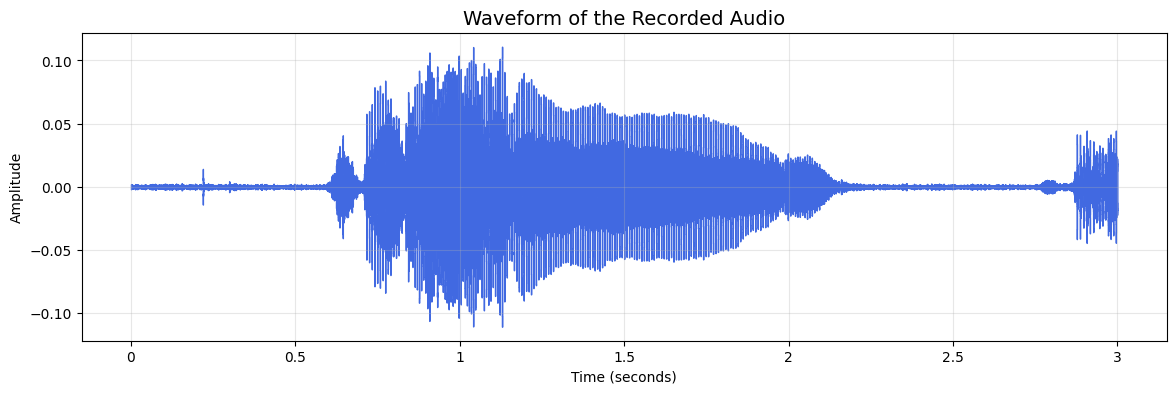

In [33]:

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr, color='royalblue')
plt.title("Waveform of the Recorded Audio", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

### 5️⃣ بزرگ‌نمایی برای مشاهده نمونه‌ها

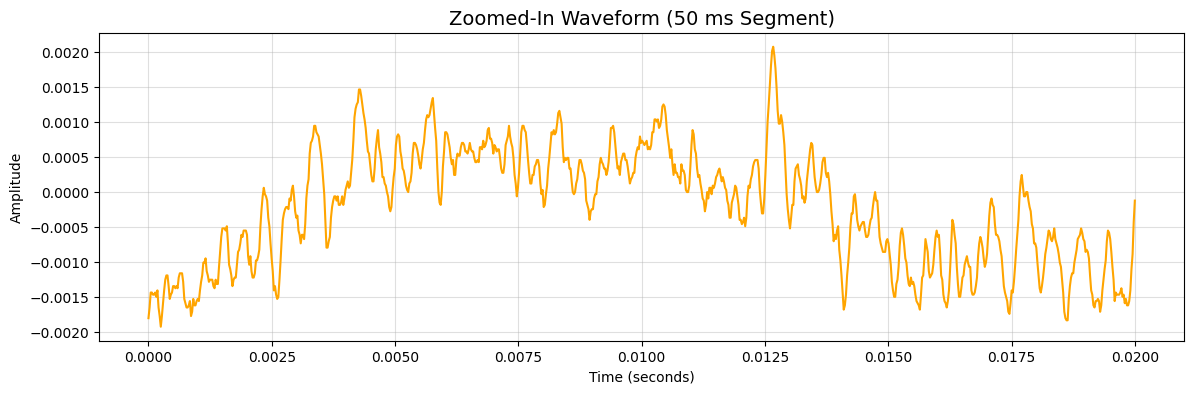

In [35]:
zoom_duration = 0.02  # seconds
end_sample = int(sr * zoom_duration)

plt.figure(figsize=(14,4))
times = np.linspace(0, zoom_duration, end_sample)
plt.plot(times, y[:end_sample], color='orange')
plt.title("Zoomed-In Waveform (50 ms Segment)", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.4)
plt.show()

### 6️⃣ مقایسه نرخ‌های نمونه‌برداری

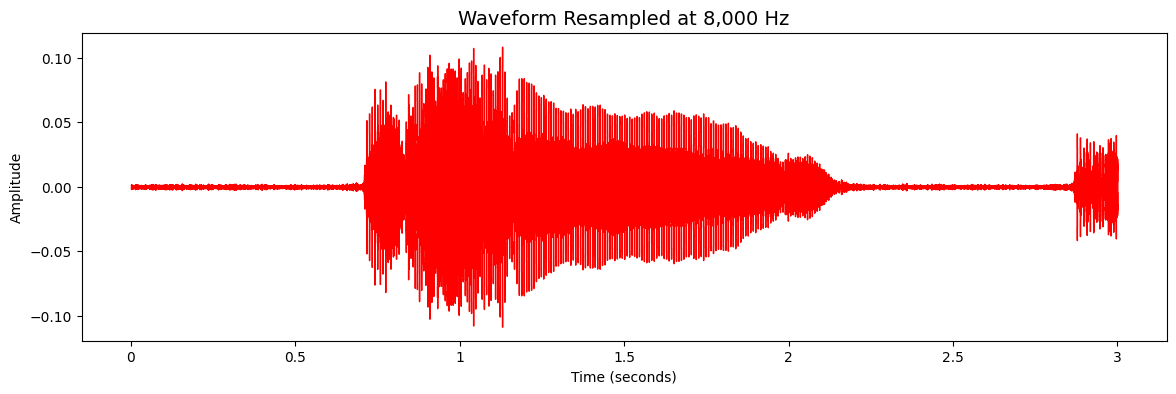

طول اولیه: 132300 نمونه | طول جدید: 24000 نمونه


In [36]:
y_8k = librosa.resample(y, orig_sr=sr, target_sr=8000)

plt.figure(figsize=(14,4))
librosa.display.waveshow(y_8k, sr=8000, color='red')
plt.title("Waveform Resampled at 8,000 Hz", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

print(f"طول اولیه: {len(y)} نمونه | طول جدید: {len(y_8k)} نمونه")

### 7️⃣ مقایسه بصری  

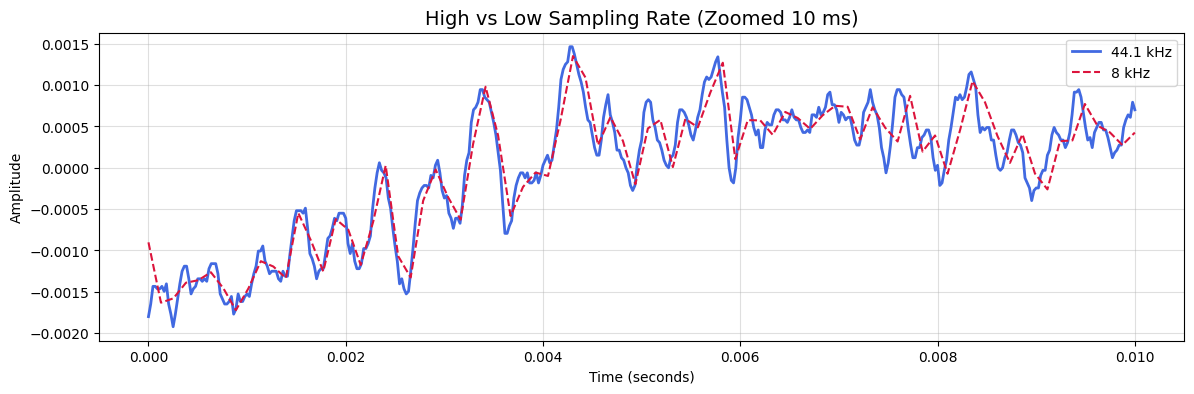

In [37]:
segment = int(0.01 * sr)  # 10 ms
time_high = np.linspace(0, 0.01, segment)
time_low = np.linspace(0, 0.01, int(0.01 * 8000))

y_high = y[:segment]
y_low  = y_8k[:len(time_low)]

plt.figure(figsize=(14,4))
plt.plot(time_high, y_high, label='44.1 kHz', color='royalblue', linewidth=2)
plt.plot(time_low, y_low, label='8 kHz', color='crimson', linestyle='--')
plt.title("High vs Low Sampling Rate (Zoomed 10 ms)", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

 سیگنال ۸ کیلوهرتز تعداد «نمونه»‌های کمتری دارد؛ بنابراین جزئیات کمتری ثبت می‌شود و بخشی از فرکانس‌های بالا (جزئیات ظریف صدا) از دست می‌روند.




### 8️⃣ تمرین ساده: تولید موج سینوسی

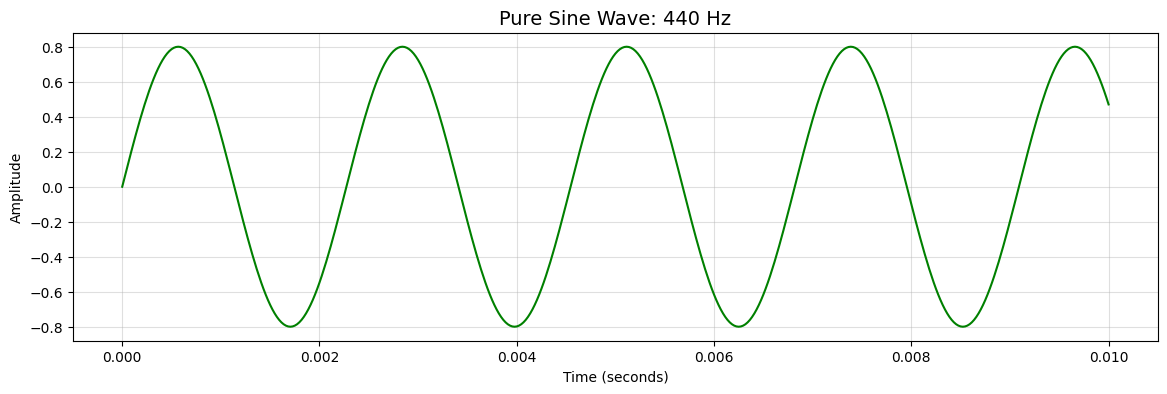

In [38]:
A = 0.8
f = 440  
t = np.linspace(0, 0.01, int(sr*0.01))  

y_sine = A * np.sin(2 * np.pi * f * t)

plt.figure(figsize=(14,4))
plt.plot(t, y_sine, color='green')
plt.title("Pure Sine Wave: 440 Hz", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.4)
plt.show()

### 🏁 جمع‌بندی



امروز یاد گرفتید:

- صدا یک **ارتعاش فیزیکی** است که می‌توان آن را با **موج سینوسی** مدل کرد  
- دیجیتالی‌سازی، موج پیوسته را به **نمونه‌های گسسته** تبدیل می‌کند  
- **نرخ نمونه‌برداری** میزان وفاداری بازتولید صدا را تعیین می‌کند  
- **عمق بیت** دقت دامنه صدا را مشخص می‌کند  

ما موارد زیر را به‌صورت بصری مشاهده کردیم:

- شکل موج صدا (Waveform)  
- بزرگ‌نمایی نمونه‌ها  
- مقایسه نرخ‌های نمونه‌برداری **۴۴٫۱ کیلوهرتز** و **۸ کیلوهرتز**  

و حتی **صدای خودمان را هم ضبط کردیم**

**درس بعدی:**  
«رمزگشایی صدا با تبدیل فوریه» 🎼
